In [29]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("eye_tracking_dataset.csv")

# lihat sekilas
print(df.head())
print(df["label"].value_counts())

   avg_velocity  max_velocity  std_velocity  total_distance  fixation_ratio  \
0      0.490741      2.591705      0.718205        5.392815        0.066667   
1      0.451843      2.233097      0.664036        4.890438        0.066667   
2      0.220778      0.669153      0.201033        2.413689        0.100000   
3      0.338463      1.671495      0.422953        3.687045        0.000000   
4      0.361596      2.403731      0.588044        3.899846        0.033333   

   unique_area_count                                       file   label  
0                  7  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
1                  4  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
2                  5  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
3                  5  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
4                  5  47012b2f-426a-41f7-a6cb-1908b8881cdc.json  tinggi  
label
tinggi    56
sedang    41
Name: count, dtype: int64


In [21]:
X = df.drop(columns=["file", "label"])
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)  # untuk cek mapping label

['sedang' 'tinggi']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [23]:
model = SVC(
    kernel="rbf",   # bisa coba: linear / poly / rbf
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

In [24]:
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [25]:
y_pred = model.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.83      0.62      0.71         8
           1       0.79      0.92      0.85        12

    accuracy                           0.80        20
   macro avg       0.81      0.77      0.78        20
weighted avg       0.80      0.80      0.79        20



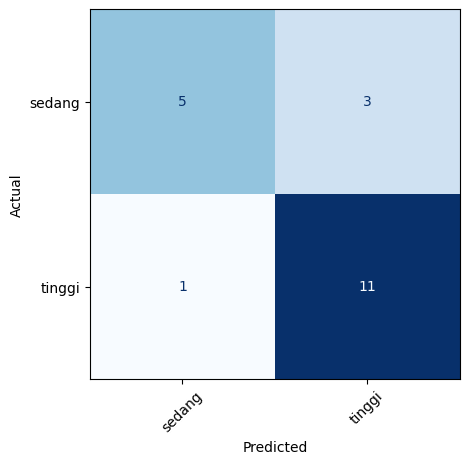

In [30]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap=plt.cm.Blues, values_format="d", xticks_rotation=45, colorbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()